____
# Closure at different depth


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter', '0.5cpd', '1.5cpd', '2.5cpd', '3cpd']),
 dict_keys(['swot250naive', 'swot250gauss1e3', 'swot250gauss2e3', 'swot250gauss3e3', 'swot250gauss4e3', 'swot250gauss5e3', 'swot2kmnaive', 'swot2kmgauss1e3', 'swot2kmgauss2e3', 'swot2kmgauss3e3', 'swot2kmgauss4e3', 'swot2kmgauss5e3', 'swot2kmgauss1e4']),
 dict_keys(['era5']))

In [3]:
def compute_mean_square(ds):
    var = ['acc', 'cor', 'ggd', 'wd','sum']
    VAR = ['ACC', 'COR', 'GGD', 'WD', 'S']
    dss = (ds[[v+'n' for v in var] + [v+'e' for v in var]]**2).mean(dim='row_number').rename({var[i]+'n' : VAR[i]+'n' for i in range(5)}).rename({var[i]+'e' : VAR[i]+'e' for i in range(5)})
    dss['sigmae'] = dss.ACCe + dss.CORe + dss.GGDe + dss.WDe
    dss['sigman'] = dss.ACCn + dss.CORn + dss.GGDn + dss.WDn
    dss['nb_coloc'] = len(ds.row_number)
    #Balanced and error
    for direction in ['e', 'n']:
        for v in ['acc', 'cor', 'ggd', 'wd'] : 
                dss['B'+direction+'_'+v] = -((ds[v+direction]*ds['exc'+direction+'_'+v])).mean(dim='row_number')
                dss['E'+direction+'_'+v] = ((ds[v+direction]*ds['sum'+direction])).mean(dim='row_number')
    #pairs contributions
    for v in [v for v in ds if 'prod' in v]:
        dss[v.replace('prod', 'X')]=-2*ds[v].mean(dim='row_number')
    return dss

_______
# Count 

In [4]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15'),]

DS = dataset_coloc_combs(comb_list, nearest=True)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')
DSS = DS.where(DS.depth==0, drop=True)
DSD = DS.where(DS.depth==15, drop=True)
DS50 = DS.where(DS.depth==50, drop=True)
DS100 = DS.where(DS.depth==100, drop=True)

dfs = (compute_mean_square(DSS)/U2).to_dataframe()
dfd =( compute_mean_square(DSD)/U2).to_dataframe()
df50 = (compute_mean_square(DS50)/U2).to_dataframe()
df100 = (compute_mean_square(DS100)/U2).to_dataframe()

df = pd.concat([dfs.iloc[0], dfd.iloc[1], df50.iloc[1], df100.iloc[1]], axis=1).transpose()
df['depth'] = np.array([0, 15, 50, 100])
df = df.reset_index().rename(columns ={'index':'id_comb'}).set_index('depth')
df

nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__swot2kmnaive_etaf__rio_15era5
Identified SWOT and drifter outliers have been removed


,id_comb,ACCn,CORn,GGDn,WDn,Sn,ACCe,CORe,GGDe,WDe,...,Xe_acc_wd,Xe_cor_ggd,Xe_cor_wd,Xe_ggd_wd,Xn_acc_cor,Xn_acc_ggd,Xn_acc_wd,Xn_cor_ggd,Xn_cor_wd,Xn_ggd_wd
depth,,,,,,,,,,,,,,,,,,,,,
0,nofilter__swot2kmnaive_etaf__rio_0era5,2.549354,4.403625,1.790185,0.046471,2.287037,2.299744,3.982237,1.501830,0.264476,...,0.006392,2.135103,0.995824,-0.114655,3.316703,-0.185777,-0.067051,3.140087,0.265730,0.032908
15,nofilter__swot2kmnaive_etaf__rio_15era5,1.158227,3.064720,2.027491,0.004118,1.362405,1.159314,2.104238,1.290414,0.030660,...,-0.011982,1.816532,0.113729,-0.009751,1.972884,-0.243888,-0.006193,3.124627,0.032140,0.012581
50,nofilter__swot2kmnaive_etaf__rio_15era5,0.201641,1.967322,3.614018,0.004234,1.927321,0.188865,2.761277,4.059564,0.018672,...,0.002763,5.263317,0.098520,-0.125715,0.416549,-0.211927,-0.009007,3.632206,-0.012065,0.044137
100,nofilter__swot2kmnaive_etaf__rio_15era5,0.106098,0.804020,1.118315,0.004491,0.531361,0.112397,0.676557,1.169994,0.072997,...,0.008489,0.932919,0.005494,-0.000635,0.298085,-0.137444,-0.010167,1.319481,0.041164,-0.009557


8.048285799495584
8.59792918217565
8.78963546877884
9.130359668661567
4.584624887024357
4.775857408868939
6.254555375214038
6.567182481702559
7.028379307304472
7.224378474826535
5.787215013502905
6.078085229708247
2.031944553828993
2.1308038299288006
2.0329238351495134
2.2104208274073085


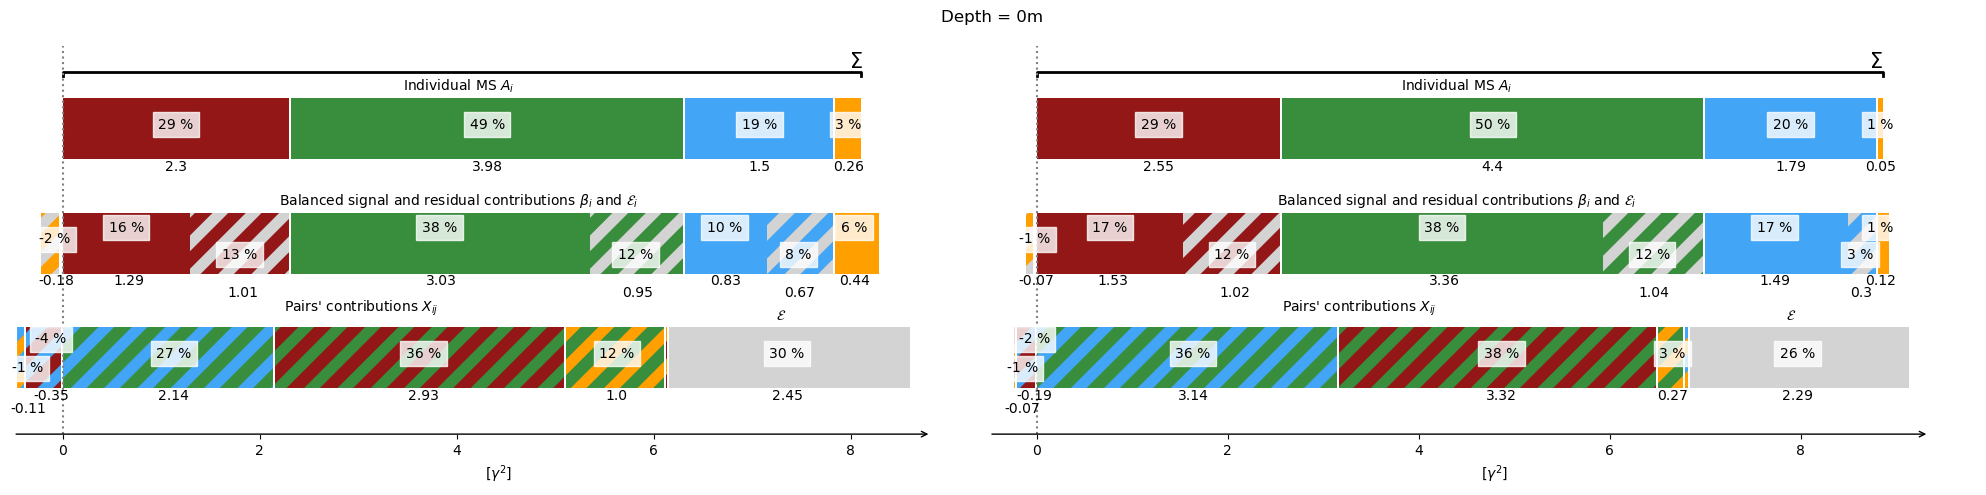

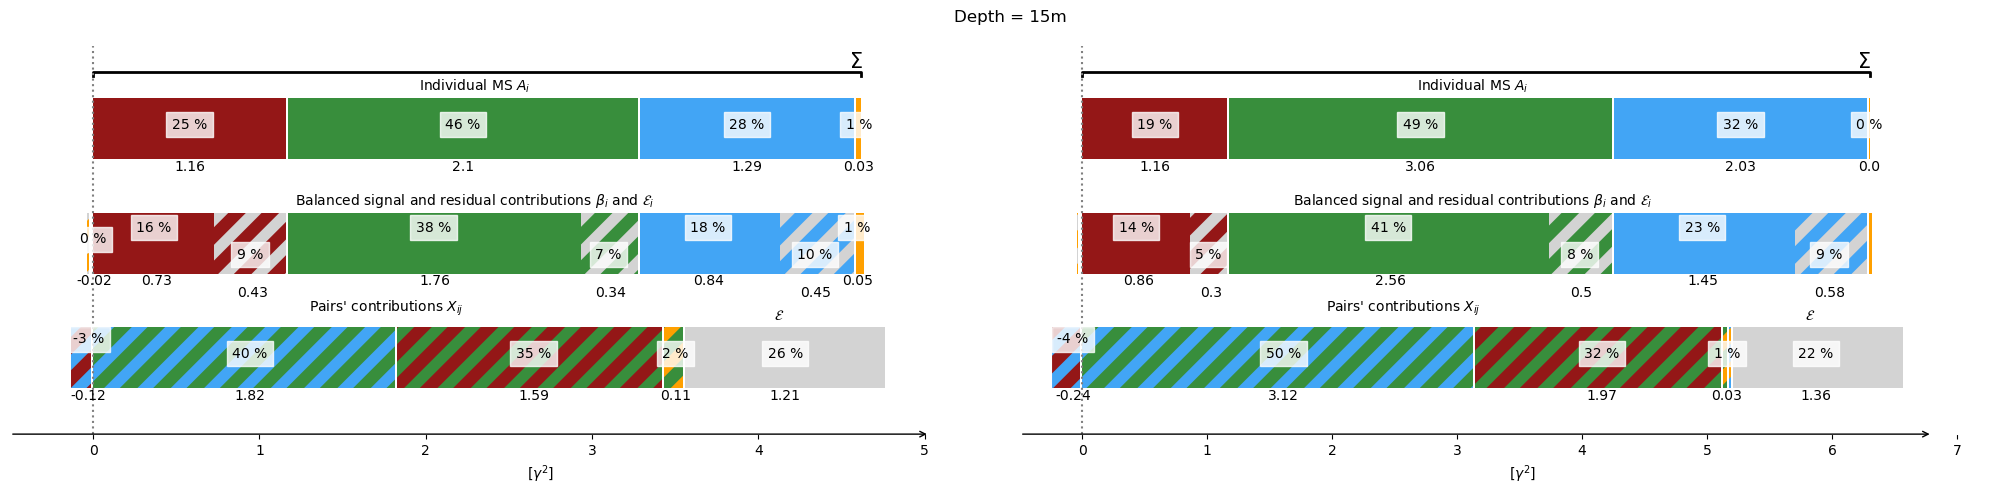

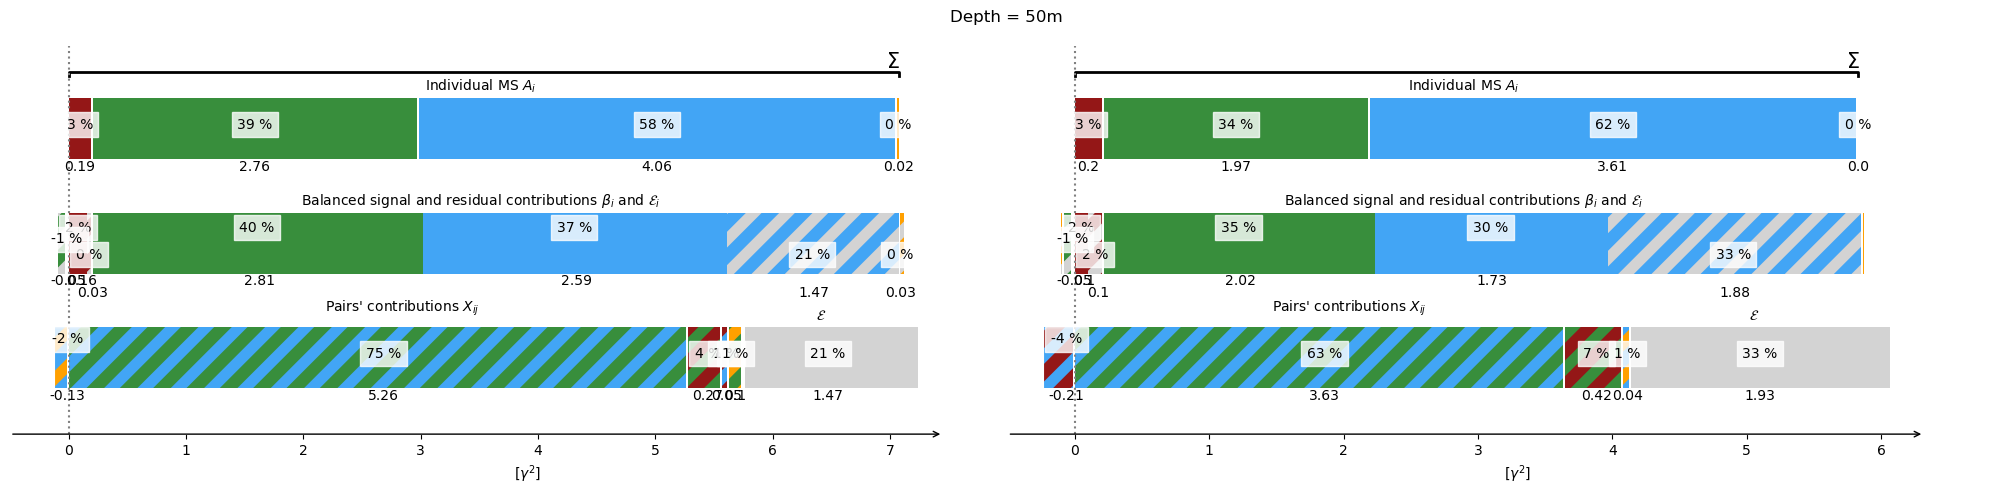

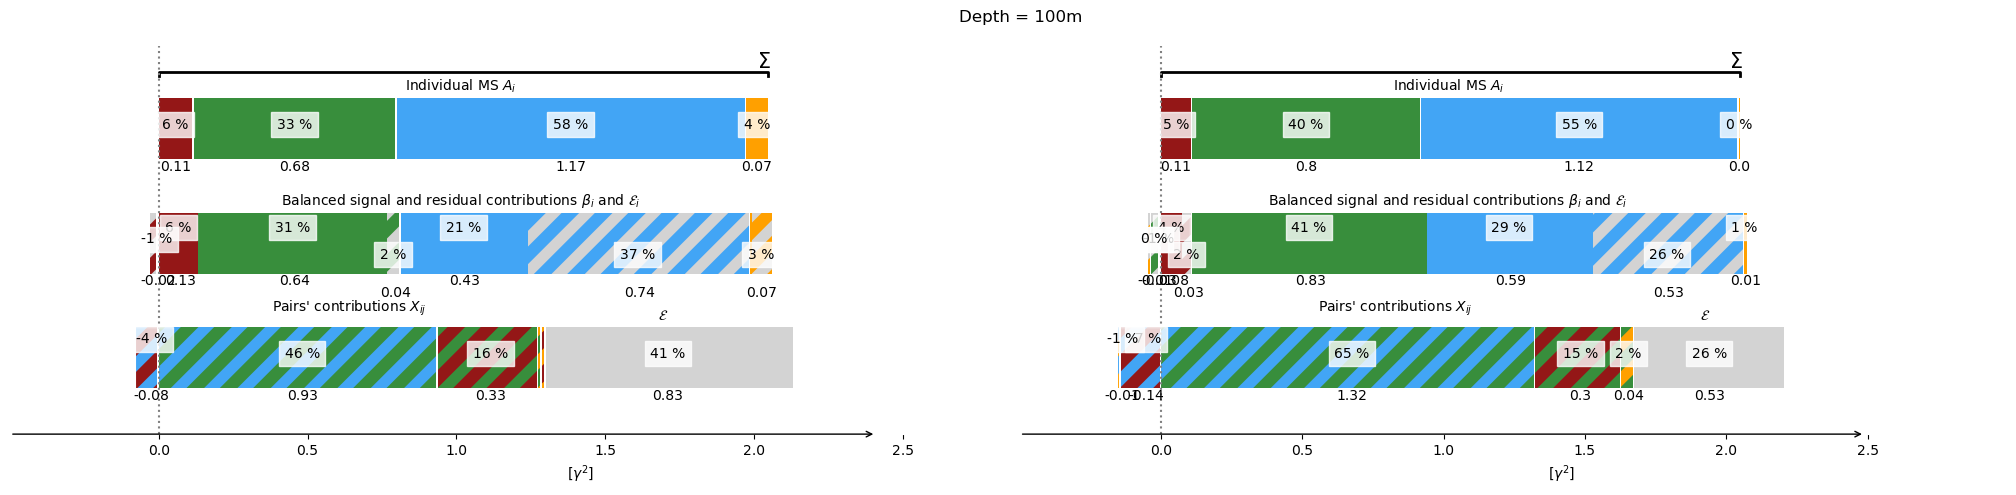

In [6]:
for c in [0, 15, 50, 100] :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e')
    synthetic_figure(df.loc[c], axs[1], dir='n')
    fig.suptitle(f'Depth = {c}m')
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', f'depth_{c}.png'))